In [20]:
import matplotlib.pyplot as plt
from infinite_str_stream_generation import infinite_str_stream_generation
from hyperloglog import HyperLogLog
import pandas as pd
import numpy as np

In [21]:
def calculate_hll_error(n: int, eps: float, num_trials: int = 3):
    results = []
    for _ in range(num_trials):
        hll = HyperLogLog.make_hpp_with_specified_accuracy(eps=eps)

        elements_to_add = set()
        while len(elements_to_add) < n:
            element = next(infinite_str_stream_generation())
            if element not in elements_to_add:
                elements_to_add.add(element)
                hll.add(element)

        card = hll.cardinality()
        error = abs(card - n) / n
        results.append(error)

    mean_error = np.mean(results)
    var_of_error = np.var(results)

    return mean_error, var_of_error, hll.p, hll.m

In [22]:
n_values = (25000, 250000, 10**6)

eps_values = (0.7, 0.15, 0.05)

results_of_experiments = []

for n in n_values:
    for eps in eps_values:
        mean, var, p, m = calculate_hll_error(n=n, eps=eps, num_trials=3)

        theoretical_std_err = 1.04 / np.sqrt(m)

        results_of_experiments.append({
            "n": n,
            "p": p, "m": m,
            "eps": eps,
            "theory_value": theoretical_std_err,
            "mean": mean,
            "per_mean": mean*100,
            "var": var,
            "per_var": var * 100
        })

results_of_experiments_df = pd.DataFrame(results_of_experiments)


In [23]:
results_of_experiments_df

,n,p,m,eps,theory_value,mean,per_mean,var,per_var
0,25000,2,4,0.70,0.520000,0.258027,25.802667,0.006157,0.615723
1,25000,6,64,0.15,0.130000,0.039840,3.984000,0.000866,0.086596
2,25000,9,512,0.05,0.045962,0.032040,3.204000,0.000151,0.015130
3,250000,2,4,0.70,0.520000,0.176183,17.618267,0.019534,1.953368
4,250000,6,64,0.15,0.130000,0.120008,12.000800,0.009032,0.903209
5,250000,9,512,0.05,0.045962,0.029269,2.926933,0.000163,0.016291
6,1000000,2,4,0.70,0.520000,0.285433,28.543333,0.029199,2.919895
7,1000000,6,64,0.15,0.130000,0.053058,5.305767,0.000443,0.044321
8,1000000,9,512,0.05,0.045962,0.024079,2.407933,0.000390,0.038994


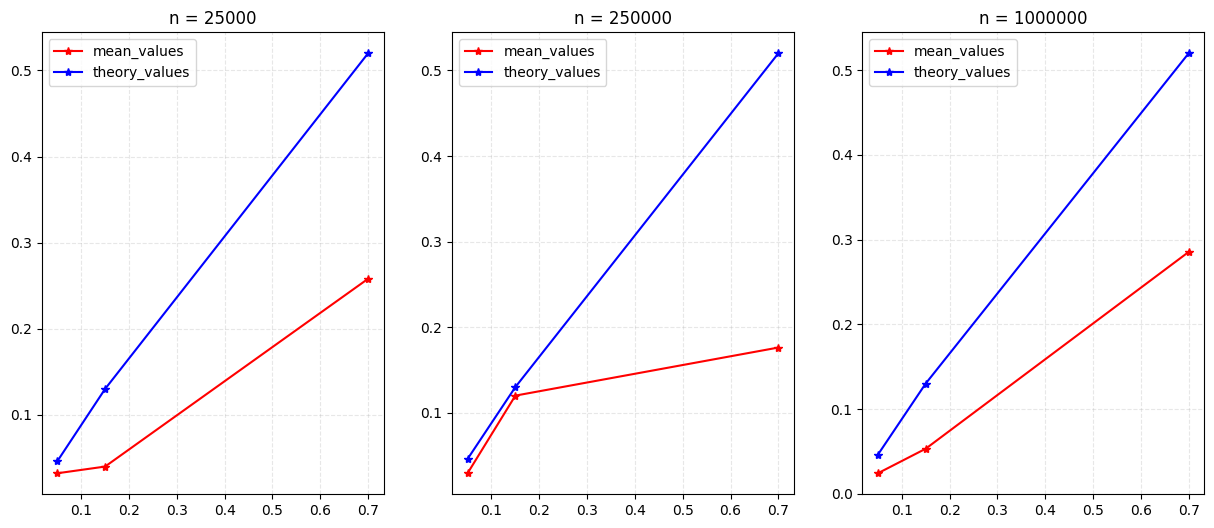

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

for ax, n in zip(axes, results_of_experiments_df["n"].unique()):
    data_with_curr_n = results_of_experiments_df[results_of_experiments_df["n"] == n]
    ax.plot(data_with_curr_n["eps"], data_with_curr_n["mean"], marker="*", color="red", label="mean_values")
    ax.plot(data_with_curr_n["eps"], data_with_curr_n["theory_value"], marker="*", color="blue", label="theory_values")

    ax.set_title(f"n = {n}")
    ax.legend()
    ax.grid(True, alpha=0.3, linestyle='--')

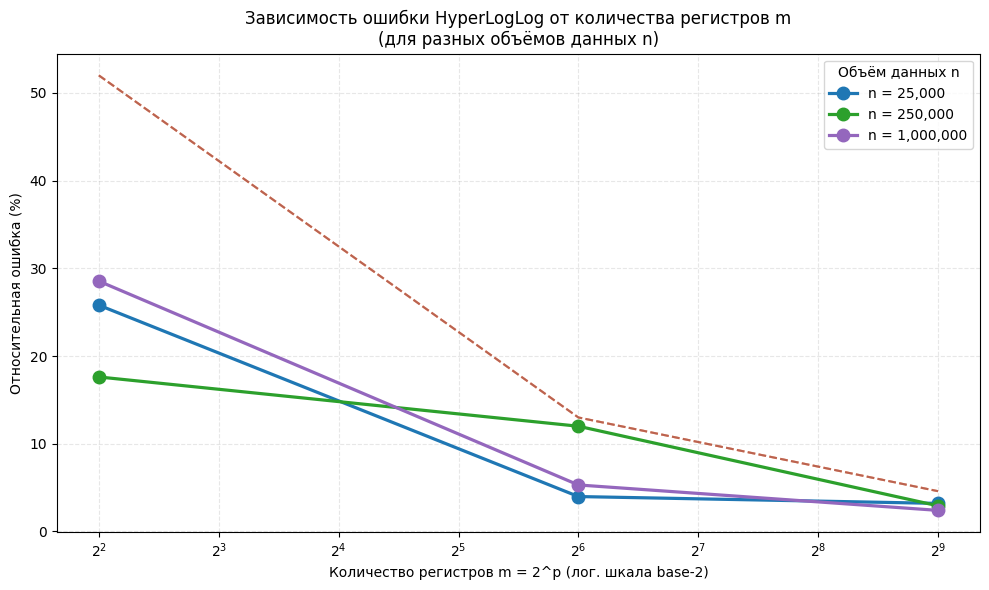

In [29]:
plt.figure(figsize=(10, 6))

for n_val in sorted(df["n"].unique()):
    subset = df[df["n"] == n_val].sort_values("m")

    plt.plot(subset["m"], subset["per_mean"],
             'o-', linewidth=2.3, markersize=9,
             label=f'n = {n_val:,}')

    plt.plot(subset["m"], subset["theory_value"]*100, '--',
             alpha=0.5, linewidth=1.5)

plt.xscale('log', base=2)
plt.xlabel('Количество регистров m = 2^p (лог. шкала base-2)')
plt.ylabel('Относительная ошибка (%)')
plt.title('Зависимость ошибки HyperLogLog от количества регистров m\n(для разных объёмов данных n)')
plt.legend(title='Объём данных n', loc='upper right', fontsize=10)
plt.grid(True, which="both", linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()